<a href="https://colab.research.google.com/github/mesianor/EJ1GIT/blob/main/proyecto1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
# Librerías para el manejo de datos
import pandas as pd
import numpy as np
# Librerías para creación de gráficos
import matplotlib.pyplot as plt
# Librerías para pruebas estadísticas
from scipy import stats as st
import math as mt
# Libreria para importar directamente desde Kaggle
import kagglehub
# Extra: acceso a comandos del Sistema Operativo
import os

try:
    athlete = pd.read_csv("athlete_recovery_synthetic.csv")
    print("Dataset cargado desde el archivo local 'athlete_recovery_synthetic.csv'")
except Exception:
    print("No se encontró 'athlete_recovery_synthetic.csv' en el entorno local.")
    print("Descargando dataset desde Kaggle...")
    ruta_dataset = kagglehub.dataset_download("sarveshchhetri/athlete-recovery-and-biometric-performance-dataset")
    ruta_csv = os.path.join(ruta_dataset, "athlete_recovery_synthetic.csv")
    athlete = pd.read_csv(ruta_csv)
    print("Dataset descargado y cargado correctamente desde Kaggle")


No se encontró 'athlete_recovery_synthetic.csv' en el entorno local.
Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'athlete-recovery-and-biometric-performance-dataset' dataset.
Dataset descargado y cargado correctamente desde Kaggle


En este proyecto se utilizo un dataset con información de atletas, que incluye variables relacionadas con el entrenamiento, el descanso y el estado físico. El objetivo es analizar qué factores influyen en la recuperación de un atleta y construir un modelo de Machine Learning capaz de predecir el Recovery Score.


In [37]:
print(athlete.head(5))        # imprime las primeras 5 filas en consola

   Athlete_ID  Day  Day_of_Week  Week  Age Gender  Sport_Type Training_Type  \
0        1000    1            1     1   28   Male  Team Sport          HIIT   
1        1000    2            2     1   28   Male  Team Sport        Cardio   
2        1000    3            3     1   28   Male  Team Sport          HIIT   
3        1000    4            4     1   28   Male  Team Sport        Cardio   
4        1000    5            5     1   28   Male  Team Sport          HIIT   

   Training_Duration_Min  Training_Intensity  Sleep_Duration_Hours  \
0                     46                 7.9                   7.7   
1                     71                 7.0                   7.3   
2                     45                 7.3                   7.7   
3                     86                 7.5                   7.9   
4                     28                 9.2                   6.7   

   Caffeine_Intake_mg Stress_Level  Resting_Heart_Rate  HRV_ms  Mood_Score  \
0                 270     

In [38]:
display(athlete.head())

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3


In [39]:
print("\nInformación general del dataset:")
athlete.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete_ID             8379 non-null   int64  
 1   Day                    8379 non-null   int64  
 2   Day_of_Week            8379 non-null   int64  
 3   Week                   8379 non-null   int64  
 4   Age                    8379 non-null   int64  
 5   Gender                 8379 non-null   object 
 6   Sport_Type             8379 non-null   object 
 7   Training_Type          8379 non-null   object 
 8   Training_Duration_Min  8379 non-null   int64  
 9   Training_Intensity     8378 non-null   float64
 10  Sleep_Duration_Hours   7775 non-null   float64
 11  Caffeine_Intake_mg     8379 non-null   int64  
 12  Stress_Level           8379 non-null   object 
 13  Resting_Heart_Rate     8379 non-null   int64  
 14  HRV_ms                

In [40]:
print("\nResumen estadístico de las variables numéricas:")
display(athlete.describe())


Resumen estadístico de las variables numéricas:


,Athlete_ID,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8378.000000,7775.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,1149.458647,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,7.498842,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,86.631832,8.078044,2.000417,1.117941,4.531092,21.357704,2.368960,0.693790,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1000.000000,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,5.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,1074.000000,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,7.000000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,1149.000000,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,7.500000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,1224.000000,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,8.000000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,1299.000000,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,9.500000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


In [41]:
print("\nNombres de las columnas:")
display(athlete.columns)


Nombres de las columnas:


Index(['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age', 'Gender',
       'Sport_Type', 'Training_Type', 'Training_Duration_Min',
       'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg',
       'Stress_Level', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score',
       'Muscle_Soreness', 'Energy_Level', 'Recovery_Score'],
      dtype='object')

In [42]:
print("\nValores faltantes por columna:")
display(athlete.isnull().sum())


Valores faltantes por columna:


,0
Athlete_ID,0
Day,0
Day_of_Week,0
Week,0
Age,0
Gender,0
Sport_Type,0
Training_Type,0
Training_Duration_Min,0
Training_Intensity,1


In [43]:
print("\nColumnas numéricas:")
display(athlete.select_dtypes(include="number").columns)
print("\nColumnas no numéricas:")
display(athlete.select_dtypes(exclude="number").columns)


Columnas numéricas:


Index(['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age',
       'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours',
       'Caffeine_Intake_mg', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score',
       'Muscle_Soreness', 'Energy_Level', 'Recovery_Score'],
      dtype='object')


Columnas no numéricas:


Index(['Gender', 'Sport_Type', 'Training_Type', 'Stress_Level'], dtype='object')

In [44]:
print("\nLos 10 valores más frecuentes de la columna 'Sleep_Duration_Hours':")
display(athlete["Sleep_Duration_Hours"].value_counts().head(10))


Los 10 valores más frecuentes de la columna 'Sleep_Duration_Hours':


,count
Sleep_Duration_Hours,
7.3,465
7.5,451
7.7,435
7.4,433
7.6,425
7.2,422
7.9,389
7.8,378
8.0,354


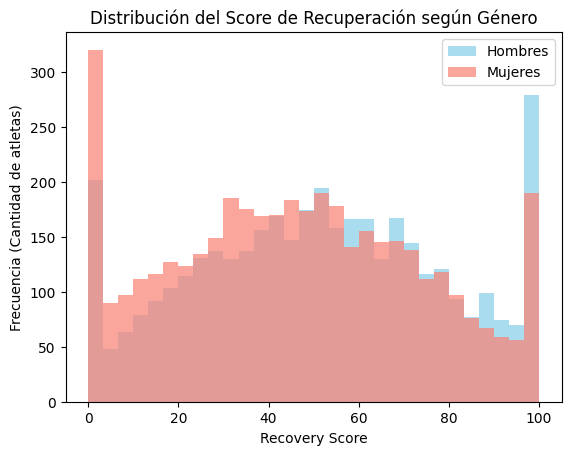

In [45]:
import matplotlib.pyplot as plt

# 1. Histograma: Para ver cómo cambia el score de recuperacion segun generos
rec_hombres = athlete[athlete["Gender"]=="Male"]["Recovery_Score"]

rec_mujeres = athlete[athlete["Gender"]=="Female"]["Recovery_Score"]

plt.hist(rec_hombres, bins=30, color="skyblue", alpha=0.7, label="Hombres")
plt.hist(rec_mujeres, bins=30, color="salmon", alpha=0.7, label="Mujeres")

plt.title("Distribución del Score de Recuperación según Género")
plt.xlabel("Recovery Score")
plt.ylabel("Frecuencia (Cantidad de atletas)")  # El eje Y siempre es el conteo

plt.legend(loc="upper right")

plt.show()

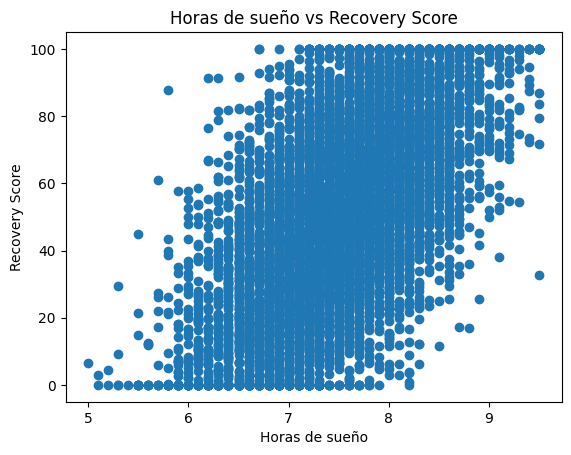

In [46]:
plt.scatter(athlete['Sleep_Duration_Hours'],
            athlete['Recovery_Score'])

plt.title('Horas de sueño vs Recovery Score')
plt.xlabel('Horas de sueño')
plt.ylabel('Recovery Score')
plt.show()

El gráfico permite observar la relacion que existe entre la cantidad de horas de sueño y el puntaje de recuperación. Los atletas que duermen más presentan mayores valores de Recovery_Score, podría indicar que el descanso tiene una influencia positiva sobre la recuperación.


In [47]:
correlacion = athlete.select_dtypes(include='number').corr()

correlacion['Recovery_Score'].sort_values(ascending=False)


,Recovery_Score
Recovery_Score,1.000000
HRV_ms,0.827900
Energy_Level,0.682012
Sleep_Duration_Hours,0.616461
Mood_Score,0.559228
Day_of_Week,0.054942
Athlete_ID,0.020496
Training_Duration_Min,-0.064701
Day,-0.141646
Week,-0.160260


Con el objetivo de identificar qué variables presentan una mayor relación con el puntaje de recuperación (Recovery_Score), se calculó la matriz de correlación utilizando únicamente las variables numéricas del dataset. Posteriormente, se seleccionaron y ordenaron las correlaciones respecto de la variable objetivo.

HRV_ms (Heart Rate Variability) presenta la correlación positiva más alta (0,828). Esto sugiere que los atletas con una mayor variabilidad de la frecuencia cardíaca tienden a mostrar mejores niveles de recuperación.
Energy_Level muestra una correlación positiva fuerte (0,682), indicando que quienes reportan mayores niveles de energía suelen obtener mejores puntajes de recuperación.
Sleep_Duration_Hours posee una correlación moderadamente alta (0,616), lo que respalda la importancia del descanso en los procesos de recuperación física.
Mood_Score también presenta una relación positiva (0,559), sugiriendo que un mejor estado de ánimo podría estar asociado con una percepción o condición general de recuperación más favorable.

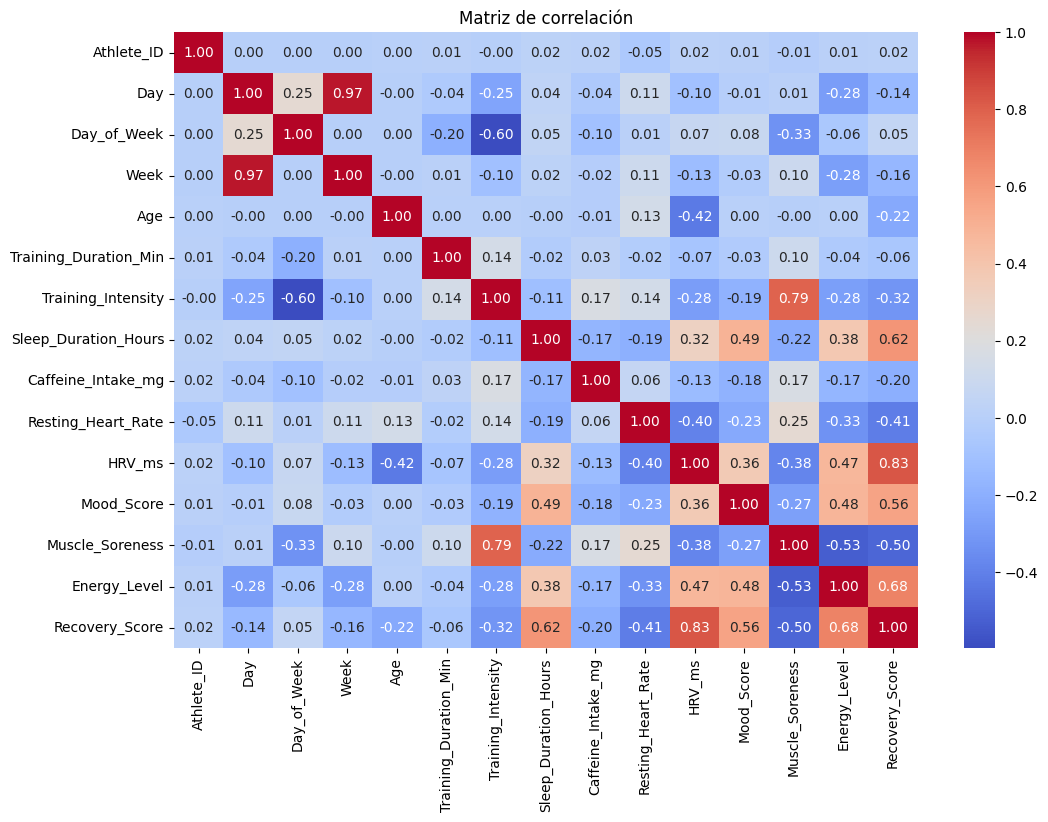

In [48]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

El mapa de calor permite visualizar rápidamente las relaciones entre todas las variables numéricas del dataset. Se observa nuevamente que HRV_ms, Energy_Level y Sleep_Duration_Hours presentan una fuerte asociación positiva con Recovery_Score.

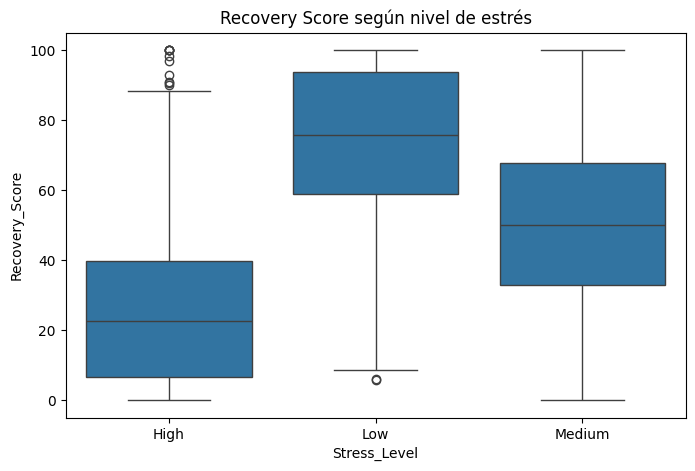

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=athlete,
    x="Stress_Level",
    y="Recovery_Score"
)

plt.title("Recovery Score según nivel de estrés")

plt.show()

Se observa que los atletas con mayor nivel de estrés presentan, en promedio, menores puntajes de recuperación, lo que coincide con la evidencia de que el estrés afecta negativamente los procesos de recuperación física.

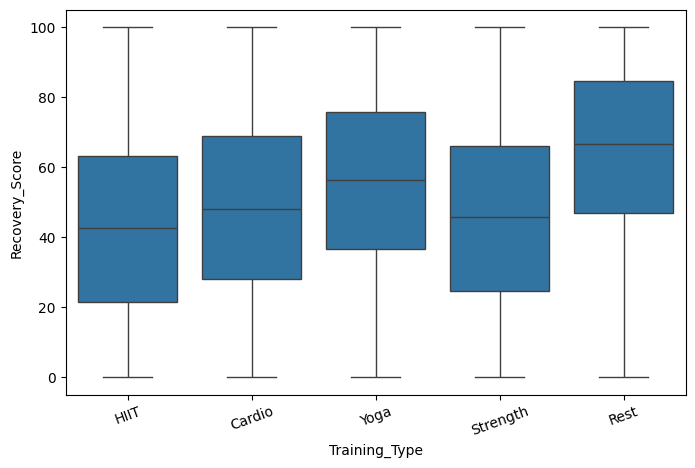

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=athlete,
    x="Training_Type",
    y="Recovery_Score"
)

plt.xticks(rotation=20)

plt.show()

Existen diferencias en el puntaje de recuperación según el tipo de entrenamiento realizado. Algunos presentan una mediana de recuperación superior a otros, lo que sugiere que el tipo de entrenamiento podría influir sobre la recuperación del atleta.

In [54]:
print("Columnas antes del One-Hot Encoding:")
print(athlete.columns.tolist())

Columnas antes del One-Hot Encoding:
['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age', 'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Recovery_Score', 'Gender_Male', 'Gender_Non-binary', 'Training_Type_HIIT', 'Training_Type_Rest', 'Training_Type_Strength', 'Training_Type_Yoga', 'Sport_Type_Endurance', 'Sport_Type_Mixed', 'Sport_Type_Strength', 'Sport_Type_Team Sport', 'Stress_Level_Low', 'Stress_Level_Medium']


In [61]:
athlete = pd.get_dummies(
    athlete,
    columns=[
        "Gender",
        "Training_Type",
        "Sport_Type",
        "Stress_Level"
    ],
    drop_first=True
)

print(athlete.columns.tolist())

['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age', 'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Recovery_Score', 'Gender_Male', 'Gender_Non-binary', 'Training_Type_HIIT', 'Training_Type_Rest', 'Training_Type_Strength', 'Training_Type_Yoga', 'Sport_Type_Endurance', 'Sport_Type_Mixed', 'Sport_Type_Strength', 'Sport_Type_Team Sport', 'Stress_Level_Low', 'Stress_Level_Medium']


Con el objetivo de preparar los datos para el entrenamiento del modelo de Machine Learning, apliqué la técnica de One-Hot Encoding sobre las variables categóricas Gender, Training_Type, Sport_Type y Stress_Level. Además, utilicé el parámetro drop_first=True, que elimina una categoría de referencia por cada variable para evitar redundancia y problemas de multicolinealidad en modelos de regresión.

In [62]:
# Variable objetivo (lo que quiero predecir)
y = athlete["Recovery_Score"]

# Variables predictoras
X = athlete.drop("Recovery_Score", axis=1)

Una vez finalizada la preparación de los datos, defino la variable objetivo (y) como Recovery_Score, ya que representa el valor que deseo predecir mediante el modelo de Machine Learning. El resto de las columnas del dataset se utilizaron como variables predictoras (X), debido a que contienen información sobre las características del atleta, el entrenamiento, el descanso y otros factores que podrían influir en su nivel de recuperación.

In [63]:
print("Cantidad de registros:", X.shape[0])
print("Cantidad de variables:", X.shape[1])

Cantidad de registros: 8379
Cantidad de variables: 26


Verifico la dimensión del conjunto de variables predictoras para confirmar que la separación se realizó correctamente. La cantidad de registros corresponde al número de observaciones disponibles para entrenar y evaluar el modelo, mientras que la cantidad de variables representa las características que el algoritmo utilizará para aprender a predecir el Recovery_Score.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [65]:
print("Conjunto de entrenamiento")
print(X_train.shape)
print(y_train.shape)

print()

print("Conjunto de prueba")
print(X_test.shape)
print(y_test.shape)

Conjunto de entrenamiento
(6703, 26)
(6703,)

Conjunto de prueba
(1676, 26)
(1676,)
